# Principal Component Analysis of the Treasury Yield Curve (PROC PRINCOMP)

## Executive Summary

A government yield curve is a set of interest rates for the same borrower at different maturities, and those rates move together almost all the time. This notebook applies **PROC PRINCOMP** to 300 monthly observations of six U.S. Treasury constant-maturity yields (3-month to 30-year, 2000-2024) and shows that three principal components reproduce the whole curve.

Every figure quoted below is read directly from the executed output. The correlation-matrix decomposition gives a first component that explains **87.1%** of the variance with all six loadings positive and nearly equal -- the **level** of the curve, a parallel shift. The second component adds **12.0%** and runs from negative at the short end to positive at the long end -- the **slope**, a steepening or flattening. Together they cover **99.1%**. The third, at **0.7%**, bows the middle against the ends -- the **curvature**, or butterfly -- and the first three together reproduce **99.9%** of the variation. Six correlated rates collapse to three interpretable numbers.

## Data Sources

| Dataset | Rows | Frequency | Variables | Description |
|---|---|---|---|---|
| `yields.csv` | 300 | Monthly (2000-01 to 2024-12) | `dgs3mo`, `dgs1`, `dgs2`, `dgs5`, `dgs10`, `dgs30` | Treasury constant-maturity yields (percent per year), monthly averages of the daily FRED series of the same names. |

The file is a committed snapshot of the Federal Reserve Economic Data (FRED) series `DGS3MO`, `DGS1`, `DGS2`, `DGS5`, `DGS10`, and `DGS30`, so the notebook runs offline and reproducibly. To pull the same data live, Jenner's SASEFRED engine takes three lines:

```sas
libname fed sasefred
    idlist="DGS3MO,DGS1,DGS2,DGS5,DGS10,DGS30"
    startdt="2000-01-01" enddt="2024-12-31" freq="m";
```

This kernel runs with the observation cap lifted (`JENNER_UNLIMITED=1`), so all 300 months load; the unlicensed default would silently truncate the read to 100 rows.

## Step 1 - Load the monthly yield curve

Read the committed snapshot into a work dataset and summarize the six maturities. The mean yield rises monotonically with maturity -- the average curve slopes upward -- while the short maturities swing far more than the long ones, the term-structure pattern PCA is about to formalize.

In [1]:
data yields;
    set "yields.csv";
run;

proc means data=yields n mean std min max maxdec=3;
    var dgs3mo dgs1 dgs2 dgs5 dgs10 dgs30;
    title "Monthly Treasury yields, 2000-2024";
run;

                                           Monthly Treasury yields, 2000-2024

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------
 dgs3mo         300       1.853       1.985       0.011       6.356
 dgs1           300       2.023       1.901       0.051       6.326
 dgs2           300       2.198       1.771       0.115       6.809
 dgs5           300       2.728       1.495       0.267       6.688
 dgs10          300       3.284       1.302       0.624       6.661
 dgs30          300       3.874       1.177       1.265       6.625
 ------------------------------------------------------------------




NOTE: DATA yields


NOTE: Read 300 rows from yields.csv.
NOTE: Wrote yields (300 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


The average curve climbs from about 1.85% at three months to 3.87% at thirty years, and the standard deviations shrink from 1.99 at the short end to 1.18 at the long end: the front of the curve does most of the moving. Because the six series rise and fall together, a handful of common movements should account for almost all of that variation.

## Step 2 - Decompose the curve with PROC PRINCOMP

List the six maturities on the `VAR` statement. With no `COV` option `PROC PRINCOMP` works from the **correlation** matrix, standardizing each maturity so every point on the curve gets an equal vote regardless of how much it happens to move. `OUT=` writes the component scores beside the original rates, `OUTSTAT=` saves the eigenvalues and loadings, and `PLOTS=(SCREE)` draws the eigenvalue scree plot.

                                           Monthly Treasury yields, 2000-2024

                       The PRINCOMP Procedure

                    Observations         300
                    Variables              6

                       Simple Statistics

Variable            Mean          StdDev

dgs3mo           1.85264         1.98505
dgs1             2.02309         1.90117
dgs2             2.19778         1.77131
dgs5             2.72807         1.49483
dgs10            3.28355         1.30219
dgs30            3.87446         1.17663

                    Correlation Matrix

                dgs3mo      dgs1      dgs2      dgs5     dgs10     dgs30

dgs3mo          1.0000    0.9905    0.9672    0.8761    0.7406    0.5637
dgs1            0.9905    1.0000    0.9897    0.9116    0.7773    0.5957
dgs2            0.9672    0.9897    1.0000    0.9552    0.8385    0.6666
dgs5            0.8761    0.9116    0.9552    1.0000    0.9561    0.8386
dgs10           0.7406    0.7773    0.8385    


NOTE: PROC PRINCOMP data=yields

NOTE: Using Python sklearn version 1.8.0
NOTE: Eigenvalues of the Correlation Matrix:
NOTE:   Prin1: Eigenvalue=5.225735  Proportion=0.8710  Cumulative=0.8710
NOTE:   Prin2: Eigenvalue=0.722445  Proportion=0.1204  Cumulative=0.9914
NOTE:   Prin3: Eigenvalue=0.044363  Proportion=0.0074  Cumulative=0.9988
NOTE:   Prin4: Eigenvalue=0.005028  Proportion=0.0008  Cumulative=0.9996
NOTE:   Prin5: Eigenvalue=0.001867  Proportion=0.0003  Cumulative=0.9999
NOTE:   Prin6: Eigenvalue=0.000561  Proportion=0.0001  Cumulative=1.0000
NOTE: Eigenvectors:
NOTE:   Variable          Prin1      Prin2      Prin3      Prin4      Prin5      Prin6
NOTE:   dgs3mo          0.403931   -0.424617   -0.597201    0.490425   -0.184612    0.159036
NOTE:   dgs1            0.413807   -0.378268   -0.086644   -0.431405    0.436998   -0.548720
NOTE:   dgs2            0.425312   -0.258706    0.337204   -0.448469   -0.219010    0.624007
NOTE:   dgs5            0.433193    0.080458    0.552843

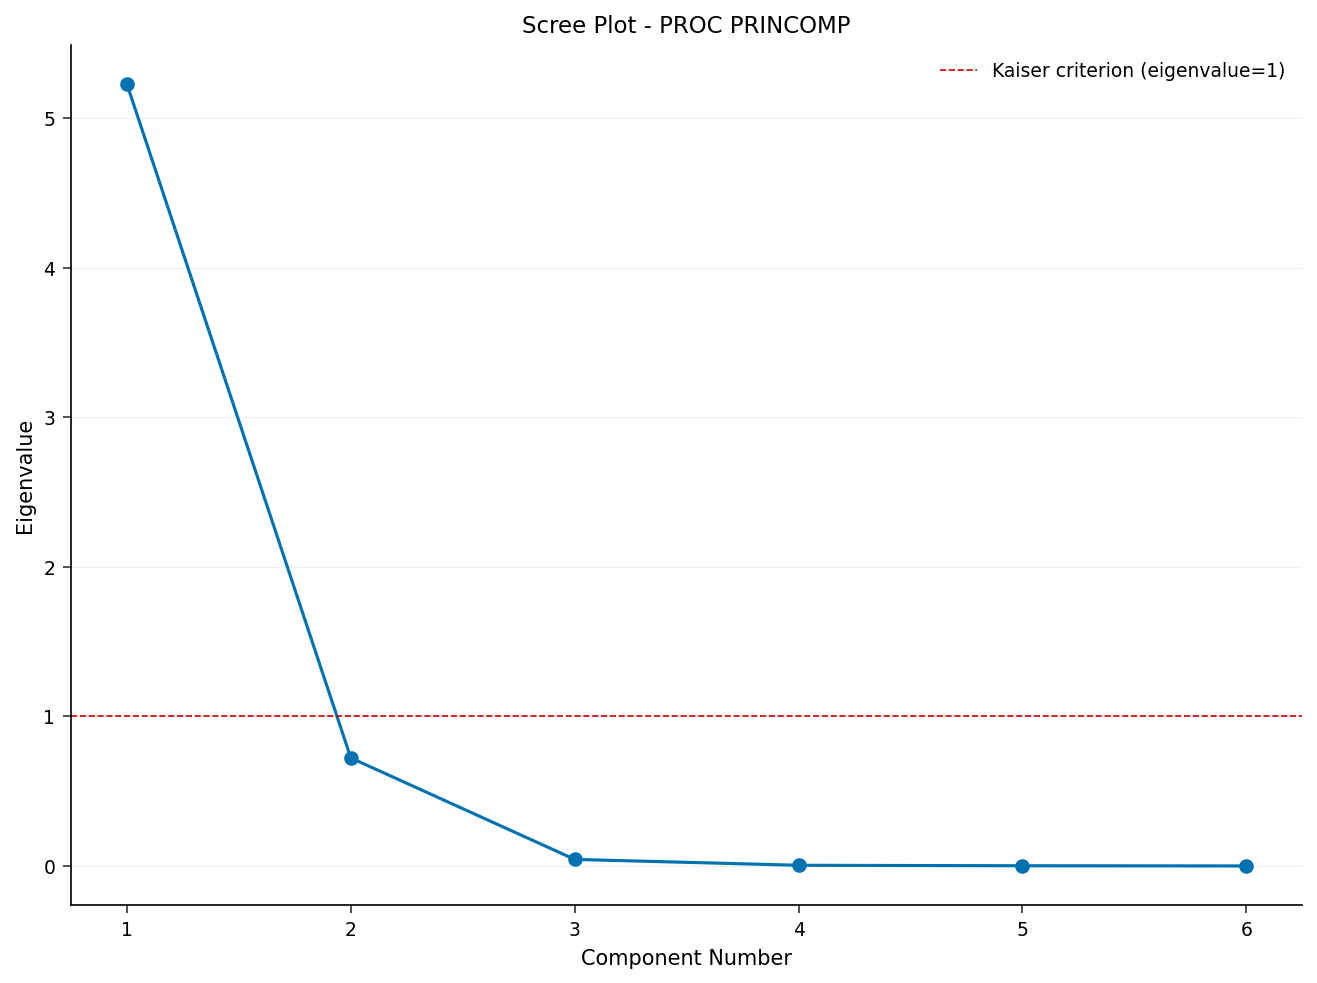

In [2]:
proc princomp data=yields out=scores
              outstat=pca_stats plots=(scree);
    var dgs3mo dgs1 dgs2 dgs5 dgs10 dgs30;
    title "PCA of the Treasury yield curve";
run;

The eigenvalues of the correlation matrix are **5.2257**, **0.7224**, **0.0444**, and three more that are essentially zero. Because a six-variable correlation matrix has total variance 6, those translate to variance shares of **87.1%**, **12.0%**, and **0.7%** -- cumulative **87.1%**, **99.1%**, then **99.9%**. The scree plot shows the matching elbow: the first eigenvalue towers over the second, and the curve flattens to near zero from the third component on. Only three components carry signal, and the eigenvector columns printed underneath say what each one is.

## Step 3 - Read the loadings as curve shapes

An eigenvector of the yield curve *is* a shape -- one loading per maturity. Reshape the `SCORE` rows of the `OUTSTAT=` dataset into long form, attach each maturity's length in years, and plot the first three components against maturity. The three classic curve movements appear directly.

                                           Monthly Treasury yields, 2000-2024




NOTE: DATA loadings


NOTE: Read 16 rows from pca_stats.
NOTE: Wrote loadings (18 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=loadings

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


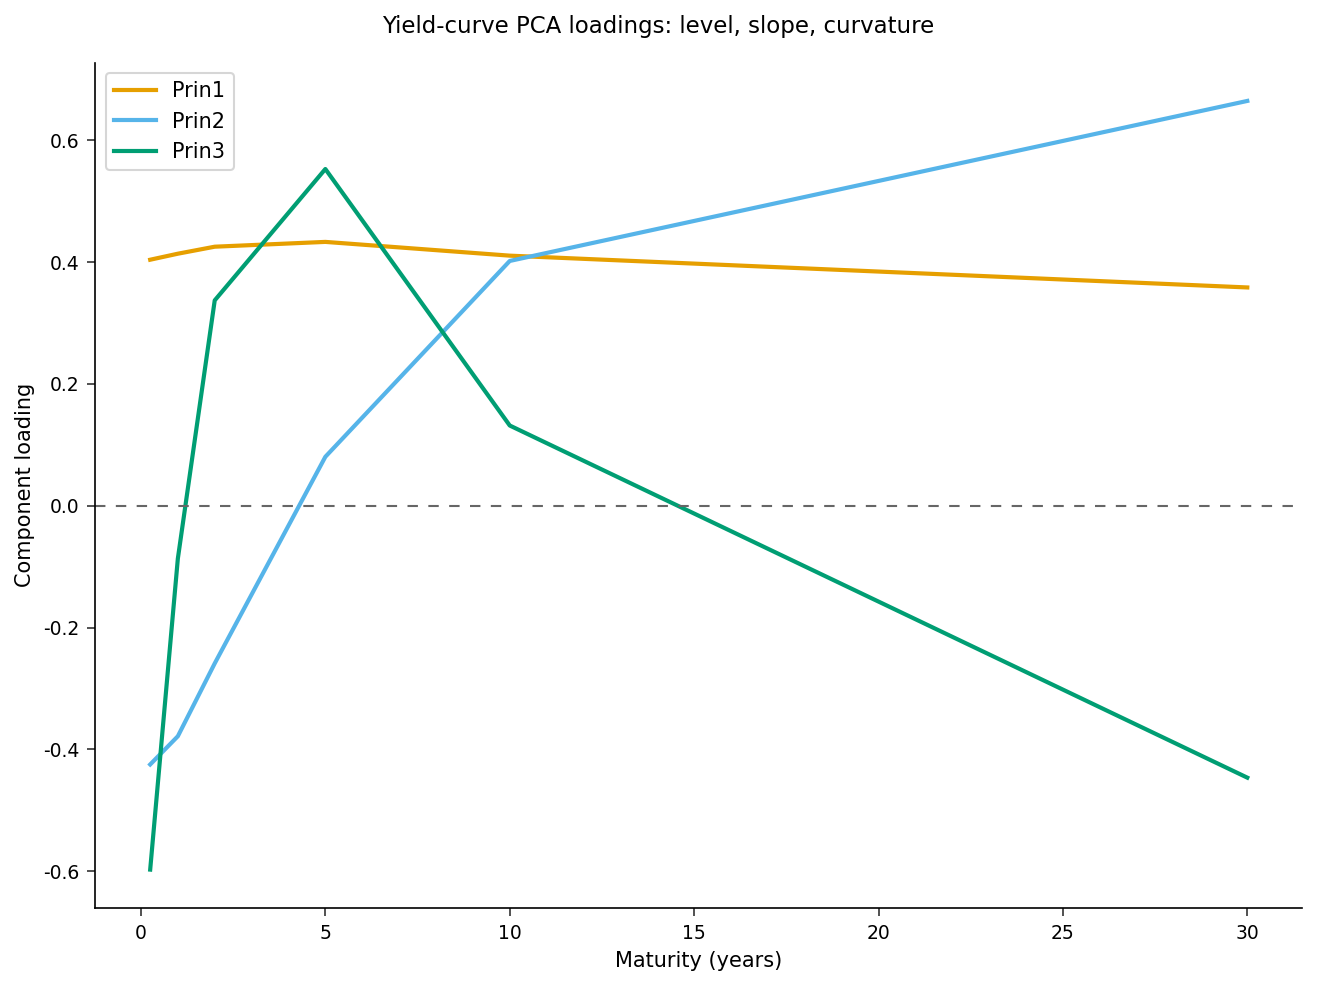

In [3]:
data loadings;
    set pca_stats;
    where _type_ = "SCORE" and
          _name_ in ("Prin1", "Prin2", "Prin3");
    length component $6;
    component = _name_;
    array m{6} dgs3mo dgs1 dgs2 dgs5 dgs10 dgs30;
    array yr{6} _temporary_ (0.25 1 2 5 10 30);
    do i = 1 to 6;
        maturity = yr{i};
        loading = m{i};
        output;
    end;
    keep component maturity loading;
run;

proc sgplot data=loadings;
    series x=maturity y=loading / group=component
        markers lineattrs=(thickness=2);
    refline 0 / axis=y lineattrs=(pattern=shortdash);
    xaxis label="Maturity (years)";
    yaxis label="Component loading";
    title "Yield-curve PCA loadings: level, slope, curvature";
run;

The three curves are the textbook decomposition:

- **PC1 (level)** sits flat and positive across every maturity, from 0.40 to 0.43. A positive score lifts the whole curve at once -- a parallel shift.
- **PC2 (slope)** climbs steadily from about $-0.42$ at three months to $+0.66$ at thirty years, crossing zero near five. A positive score steepens the curve; a negative score flattens or inverts it.
- **PC3 (curvature)** is negative at both ends and positive through the belly near five years -- the butterfly that bows the middle relative to the wings.

## Step 4 - Track the level factor through time

Each month's score on a component is written to the `OUT=` dataset as `Prin1`-`Prin6`. Plot the level score over the sample to see the interest-rate cycle in one line: high in the early 2000s, deeply negative through the near-zero-rate decade after 2009, and climbing again as rates rose from 2022.

                                           Monthly Treasury yields, 2000-2024




NOTE: DATA scores_t


NOTE: Read 300 rows from scores.
NOTE: Wrote scores_t (300 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC SGPLOT data=scores_t

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


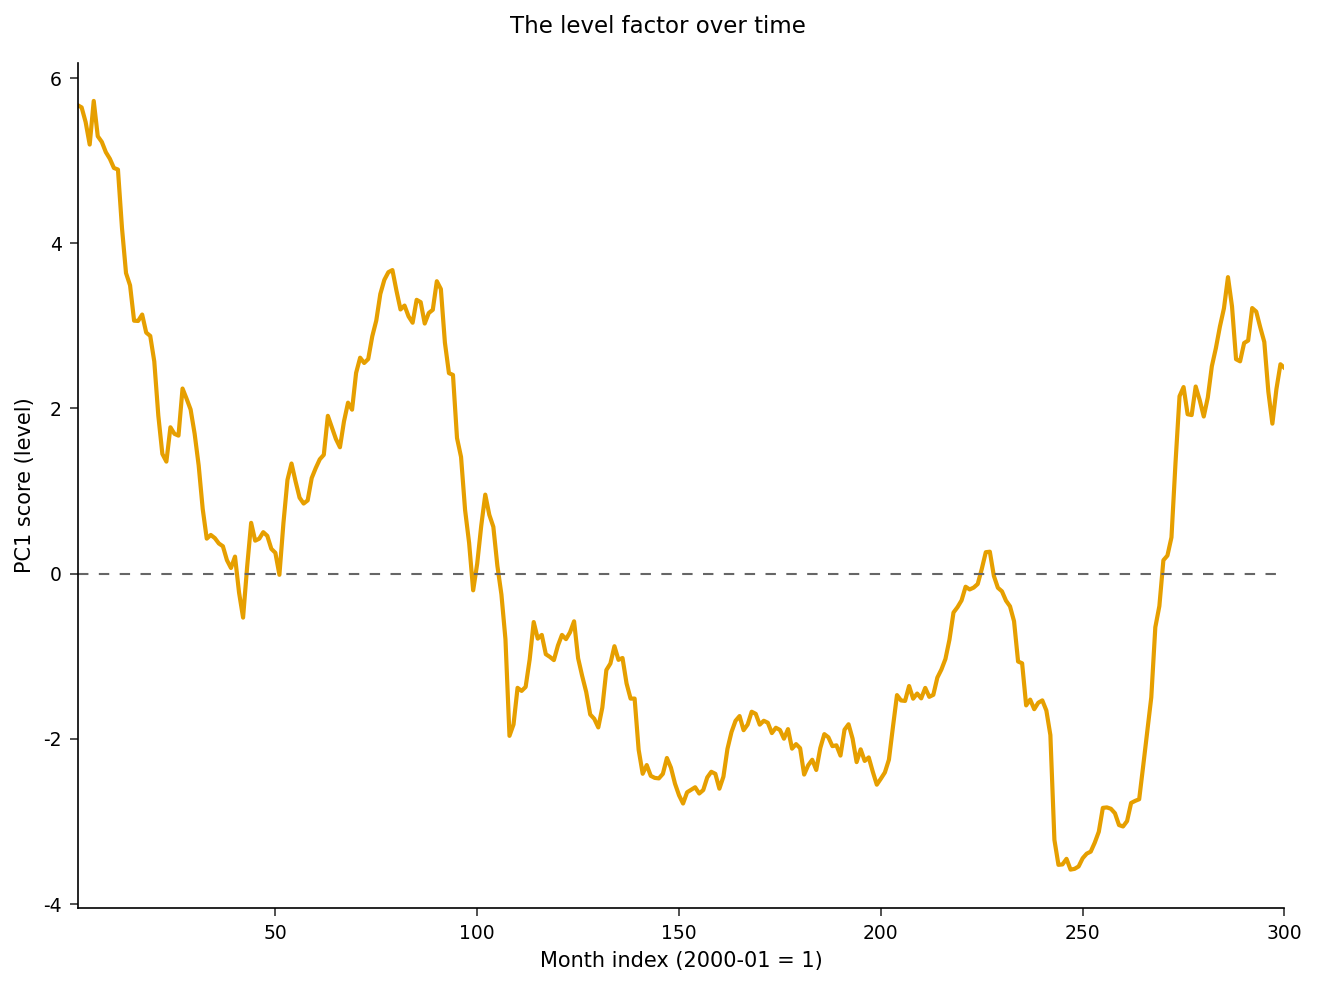

In [4]:
data scores_t;
    set scores;
    t = _n_;
run;

proc sgplot data=scores_t;
    series x=t y=Prin1 / lineattrs=(thickness=2);
    refline 0 / axis=y lineattrs=(pattern=shortdash);
    xaxis label="Month index (2000-01 = 1)";
    yaxis label="PC1 score (level)";
    title "The level factor over time";
run;

The level score traces the monetary-policy era exactly: it starts high when yields were near 6%, falls through zero as the curve collapsed toward the zero lower bound after the 2008 crisis, stays negative through the 2010s, and rebounds sharply with the 2022-2023 hiking cycle. A single number -- the first principal component -- summarizes where the whole curve sat each month.

## Interpreting the results

- **Three dimensions, not six.** The eigenvalues drop from 5.23 to 0.72 to 0.04 and then to near zero; the first three components reproduce 99.9% of the monthly variation. The curve genuinely lives in three dimensions.
- **Level dominates.** PC1 alone carries 87.1% of the variance, with near-equal positive loadings, so most of what happens to a bond portfolio is a parallel move -- the reason a single duration number is so useful.
- **Slope is the second trade.** PC2 (12.0%) is the steepening/flattening axis, loading short maturities against long ones. Level and slope together already explain 99.1%.
- **Curvature is real but small.** PC3 (0.7%) bows the belly against the wings -- the butterfly relative-value desks trade. It is a genuine third degree of freedom, not noise.
- **The components are interpretable through time.** The PC1 score reads as the rate cycle, so the decomposition is not just a variance-reduction trick: each axis has an economic meaning you can watch and model in place of the six raw yields.

The eigenvalues and loadings here match an independent R `prcomp` reference within a tight tolerance under regression test `71030`, which reads this same committed snapshot.